In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## **Data Set:**
This analysis using the **New York Stock Exchange data set** from a public Kaggle competition: http://kaggle.com/datasets/dgawlik/nyse

In [3]:
prices = pd.read_csv('/content/drive/MyDrive/Python Resources/prices.csv')
print(prices.head(n=5))

         date symbol       close       volume
0  2010-01-04   AAPL  214.009998  123432400.0
1  2010-01-04    ABT   54.459951   10829000.0
2  2010-01-04    AIG   29.889999    7750900.0
3  2010-01-04   AMAT   14.300000   18615100.0
4  2010-01-04   ARNC   16.650013   11512100.0


In [4]:
#pivot to wide format
prices["date"] = pd.to_datetime(prices["date"])
prices_wide = prices.pivot(index="date", columns="symbol", values="close")
prices_wide.columns.name = "company"
print(prices_wide.head())

company           AAPL        ABT        AIG   AMAT       ARNC        BAC  \
date                                                                        
2010-01-04  214.009998  54.459951  29.889999  14.30  16.650013  15.690000   
2010-01-05  214.379993  54.019953  29.330000  14.19  16.130013  16.200001   
2010-01-06  210.969995  54.319953  29.139999  14.16  16.970013  16.389999   
2010-01-07  210.580000  54.769952  28.580000  14.01  16.610014  16.930000   
2010-01-08  211.980005  55.049952  29.340000  14.55  17.020014  16.780001   

company      BSX     C        CHK      CMCSA  ...       QCOM    RF       SBUX  \
date                                          ...                               
2010-01-04  9.01  3.40  28.090001  16.969999  ...  46.939999  5.42  23.049999   
2010-01-05  9.04  3.53  28.970002  16.740000  ...  48.070000  5.60  23.590000   
2010-01-06  9.16  3.64  28.650002  16.620001  ...  47.599998  5.67  23.420000   
2010-01-07  9.09  3.65  28.720002  16.969999  ...  48.9

## **Plot the time series values over time**

In [5]:
#Extract several companies for this first graph
prices_1 = prices_wide[['AAPL', 'FB', 'NFLX', 'V', 'XOM']]
print(prices_1.head())

company           AAPL  FB       NFLX          V        XOM
date                                                       
2010-01-04  214.009998 NaN  53.479999  88.139999  69.150002
2010-01-05  214.379993 NaN  51.510001  87.129997  69.419998
2010-01-06  210.969995 NaN  53.319999  85.959999  70.019997
2010-01-07  210.580000 NaN  52.400001  86.760002  69.800003
2010-01-08  211.980005 NaN  53.300002  87.000000  69.519997


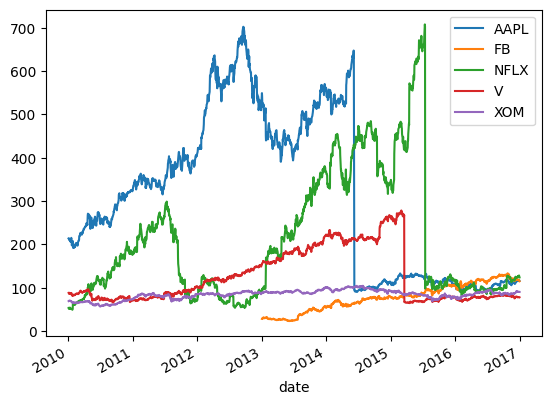

In [6]:
#Plot the the column's values over time
fig, ax = plt.subplots()
for column in prices_1:
    prices_1[column].plot(ax=ax, label=column)
ax.legend()
plt.show()

# **Simple Regression Model**
Let's use data from several companies to predict the value of a test company.

In [7]:
# Use stock symbols to extract training data
X = prices_wide.loc[:'2015-01-30', ["EBAY", "NVDA", "YHOO"]]
y = prices_wide.loc[:'2015-01-30', ["AAPL"]]

# Fit and score the model with cross-validation
scores = cross_val_score(Ridge(), X, y, cv=3)
print(scores)

[-6.09050633 -0.3179172  -3.72957284]


In [8]:
# Split our data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=False)

# Fit our model and generate predictions
model = Ridge()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
score = r2_score(y_test, predictions)
print(score)

-0.33806972562289617


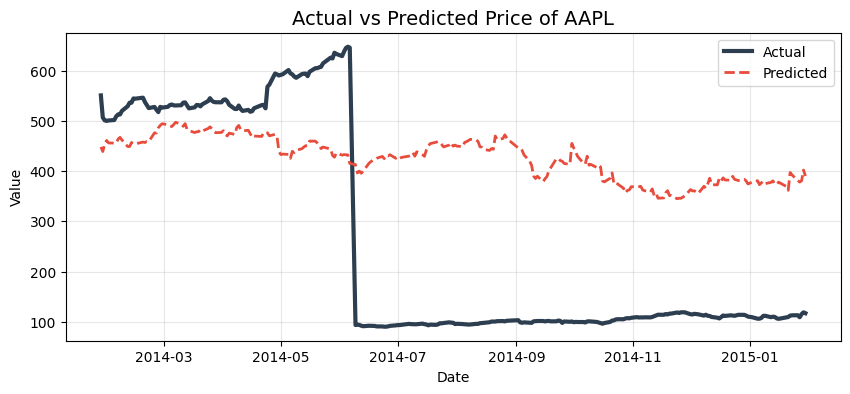

In [9]:
predictions = pd.Series(predictions, index=y_test.index)
# Visualize our predictions along with the "true" values, and print the score
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(y_test, color='#2c3e50', lw=3, label='Actual')
ax.plot(predictions, color='#e74c3c', lw=2, linestyle='--', label='Predicted')

ax.set_title('Actual vs Predicted Price of AAPL', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Value')

ax.legend()
ax.grid(alpha=0.3)

plt.show()

# **Treating Outliers**

In [10]:
prices_2 = prices_wide[["EBAY", "NVDA", "YHOO","AAPL"]]

In [11]:
prices_2.columns.name

'company'

In [12]:
prices_wide.columns.name

'company'

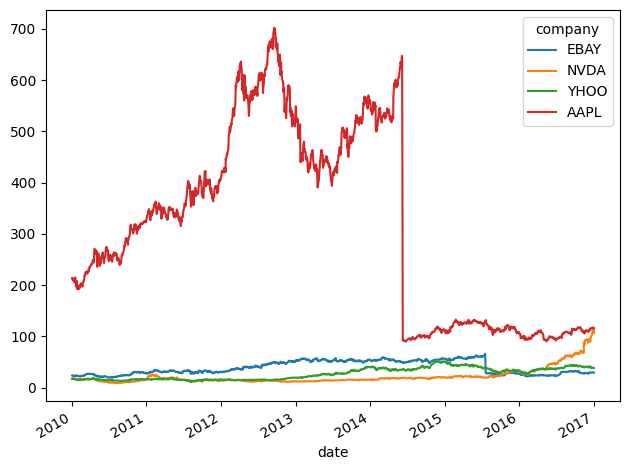

company
EBAY    0
NVDA    0
YHOO    0
AAPL    0
dtype: int64


In [13]:
# Visualize the dataset
prices_2.plot(legend=True)
plt.tight_layout()
plt.show()

# Count the missing values of each time series
missing_values = prices_2.isna().sum()
print(missing_values)

In [14]:
#Creat a function to detect the outliers
def percent_change(series):
    # Collect all *but* the last value of this window, then the final value
    previous_values = series[:-1]
    last_value = series.iloc[-1]

    # Calculate the % difference between the last value and the mean of earlier values
    percent_change = (last_value - np.mean(previous_values)) / np.mean(previous_values)
    return percent_change

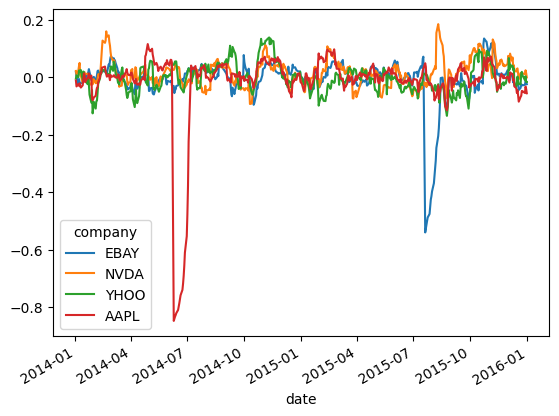

In [21]:
# Apply the function and plot
prices_perc = prices_2.rolling(20).apply(percent_change)
prices_perc.loc["2014":"2015"].plot()
plt.show()

In [22]:
# A function for treating outliers:
def replace_outliers(series):
    # Calculate the absolute difference of each timepoint from the series mean
    absolute_differences_from_mean = np.abs(series - np.mean(series))

    # Calculate a mask for the differences that are > 3 standard deviations from zero
    this_mask = absolute_differences_from_mean > (np.std(series) * 3)

    # Replace these values with the median accross the data
    series[this_mask] = np.nanmedian(series)
    return series

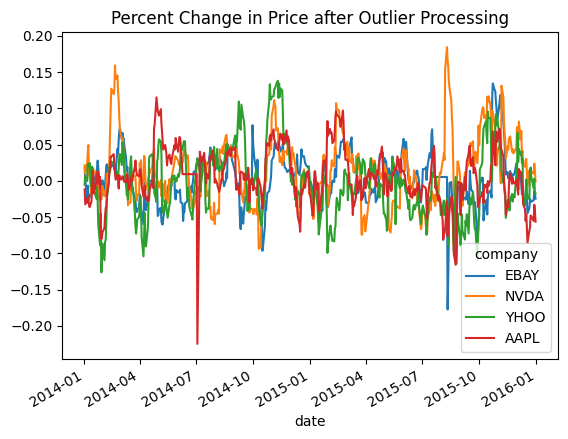

In [23]:
# Apply the above preprocessing function to the timeseries and plot the results
prices_perc = prices_perc.apply(replace_outliers)
prices_perc.loc["2014":"2015"].plot(title="Percent Change in Price after Outlier Processing")
plt.show()

# **Engineering multiple rolling features at once**

In [24]:
prices_3 = prices_wide[["EBAY"]]
prices_perc = prices_3.rolling(20).apply(percent_change)

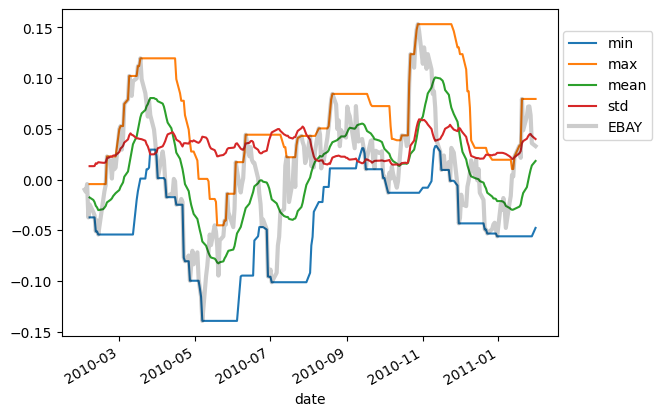

In [25]:
# Define a rolling window with Pandas, excluding the right-most datapoint of the window
prices_perc_rolling = prices_perc.rolling(20, min_periods=5, closed='right')

# Define the features you'll calculate for each window
features_to_calculate = ['min', 'max', 'mean', 'std']

# Calculate these features for your rolling window object
features = prices_perc_rolling.aggregate(features_to_calculate)

# Change the column names
features.columns = features.columns.get_level_values(1)

# Plot the results
ax = features.loc[:"2011-01"].plot()
prices_perc.loc[:"2011-01"].plot(ax=ax, color='k', alpha=.2, lw=3)
ax.legend(loc=(1.01, .6))
plt.show()